<a href="https://colab.research.google.com/github/manu2007-sym/CV-LAB-03/blob/main/CV_LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def show_comparison(original,blur3,blur5,blur7):
  plt.figure(figsize=(18,12)) # Adjusted figure size for more subplots

  plt.subplot(2,3,1)
  plt.imshow(original,cmap='gray')
  plt.title("Original Grayscale Image")
  plt.axis('off')

  plt.subplot(2,3,2)
  plt.imshow(blur3,cmap='gray')
  plt.title("Average Filter(3*3)")
  plt.axis('off')

  plt.subplot(2,3,3)
  plt.imshow(blur5,cmap='gray')
  plt.title("Average Filter(5*5)")
  plt.axis('off')

  plt.subplot(2,3,4)
  plt.imshow(blur7,cmap='gray')
  plt.title("Average Filter(7*7)")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

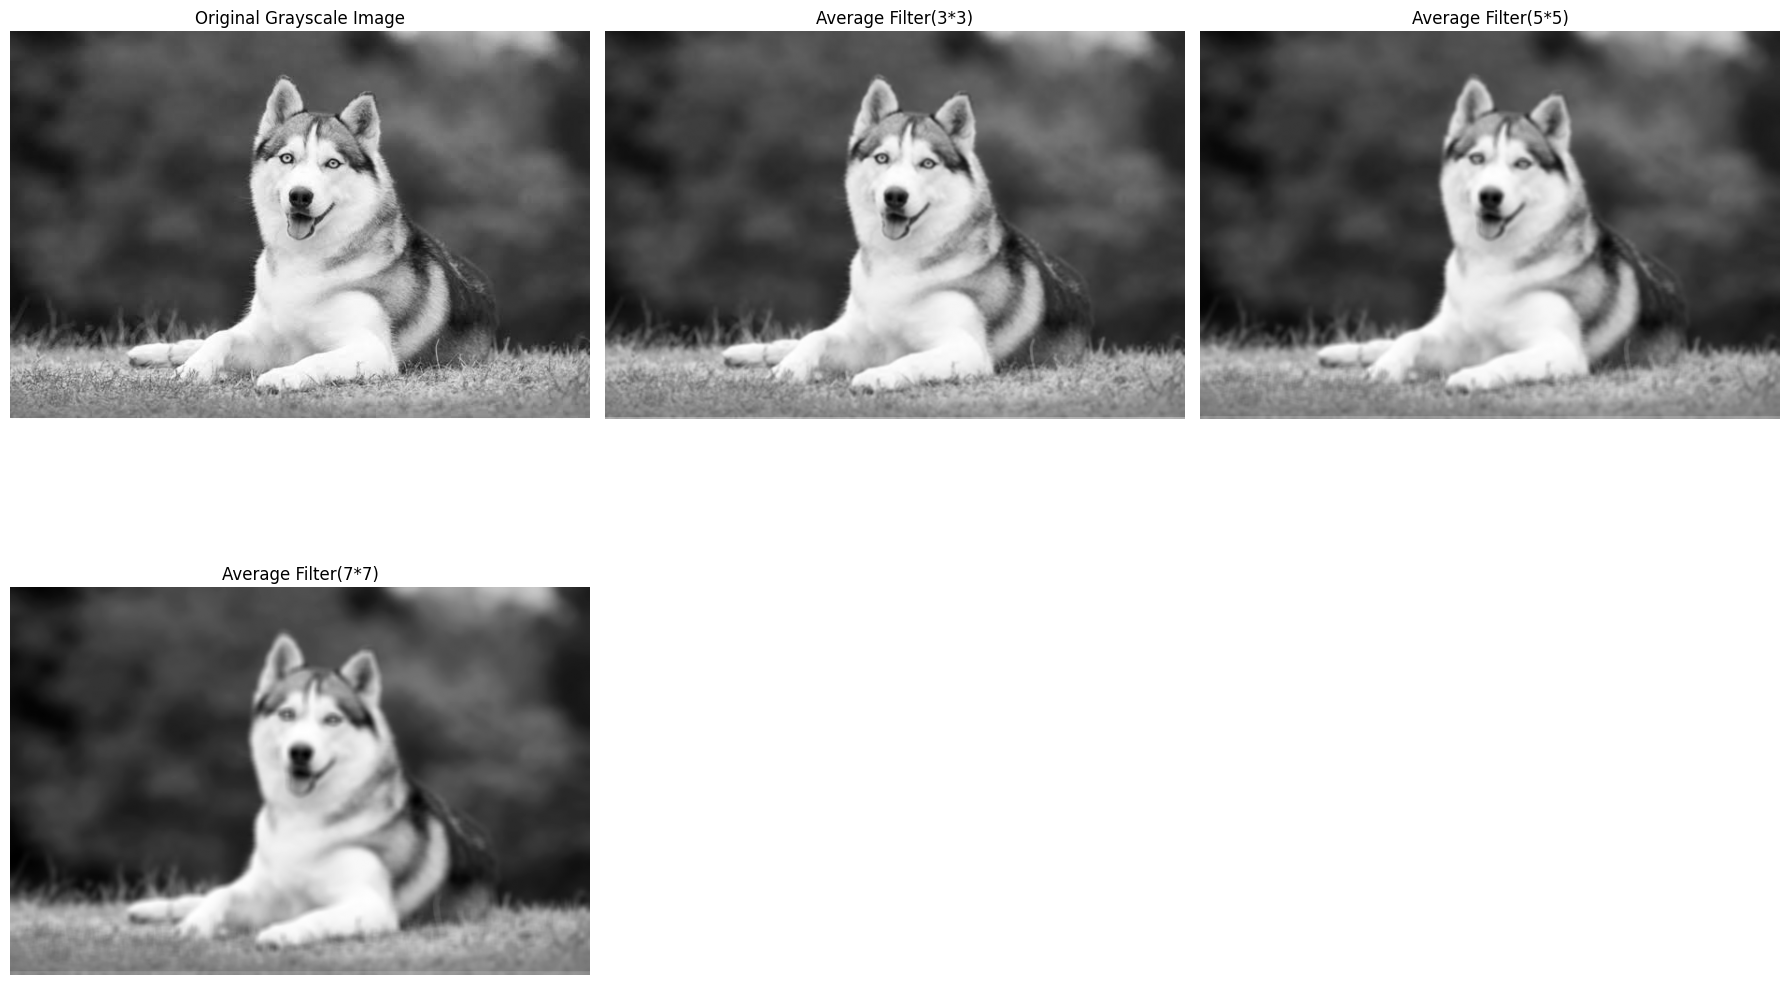

In [ ]:
img=cv2.imread("/content/husky.jpg",0)
if img is None:
  print("Error: image not found")
else:
  kernel_3x3=np.ones((3,3),np.float32)/9
  kernel_5x5=np.ones((5,5),np.float32)/25
  kernel_7x7=np.ones((7,7),np.float32)/49

  blur_3x3=cv2.filter2D(img,-1,kernel_3x3)
  blur_5x5=cv2.filter2D(img,-1,kernel_5x5)
  blur_7x7=cv2.filter2D(img,-1,kernel_7x7)

  show_comparison(img,blur_3x3,blur_5x5,blur_7x7)

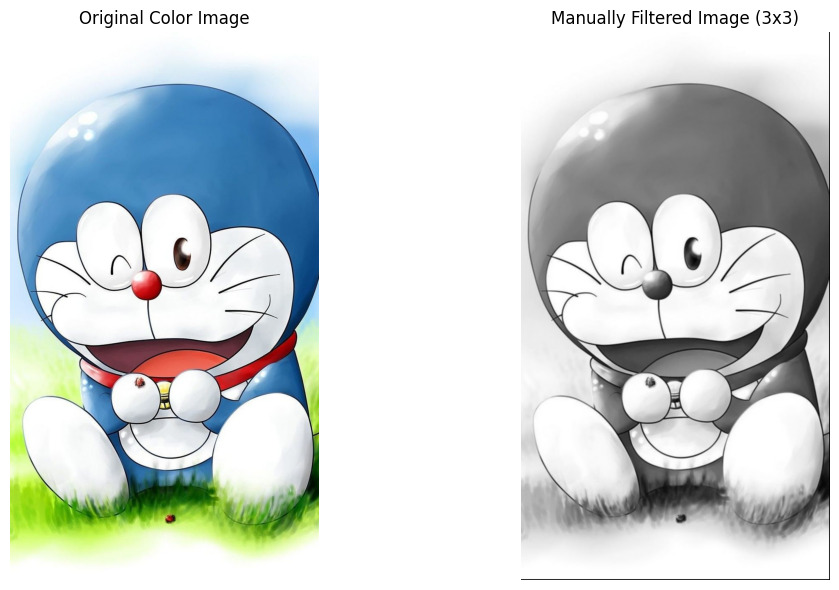

In [ ]:
k=3
p=0
s=1
kernel=np.ones((k,k),np.float32)/(k*k)

# Load original image in color
img_color = cv2.imread("/content/doremon.jpg") # Removed the '0' flag for color image

# Check if image was loaded successfully before proceeding
if img_color is None:
  print("Error: Could not load image from '/content/doremon.jpg'. Please ensure the file exists.")
else:
  # Convert color image from BGR to RGB for matplotlib display
  img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

  # Convert the color image to grayscale for filtering
  img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

  m, n = img_gray.shape # Get height (m) and width (n) of the grayscale image for filtering
  filtered_img = np.zeros_like(img_gray, dtype=np.float32)

  for i in range(m - k + 1):
    for j in range(n - k + 1):
      filtered_img[i,j] = np.sum(img_gray[i:i+k, j:j+k] * kernel)

  plt.figure(figsize=(12, 6)) # Adjusted figure size slightly for better display

  plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
  plt.imshow(img_rgb) # Display the original color image
  plt.title("Original Color Image")
  plt.axis('off')

  plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
  plt.imshow(filtered_img.astype(np.uint8), cmap='gray') # Display filtered image in grayscale
  plt.title(f"Manually Filtered Image ({k}x{k})")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

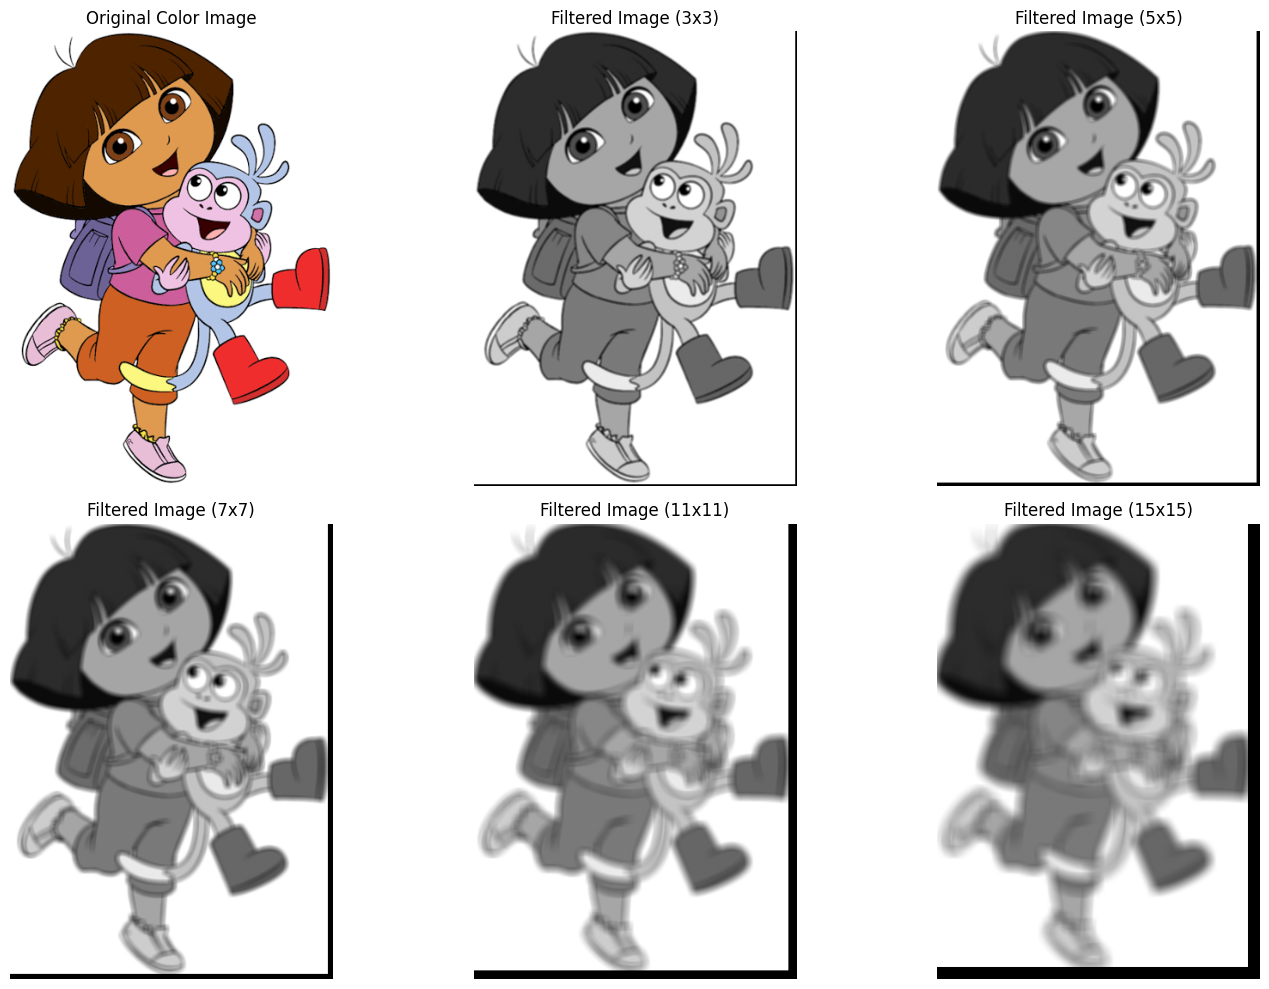

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the kernel sizes to use
kernel_sizes = [3, 5, 7, 11, 15]

# Load original image in color
img_color = cv2.imread("/content/dorabujji.png")

# Check if image was loaded successfully before proceeding
if img_color is None:
  print("Error: Could not load image from '/content/dorabujji.png'. Please ensure the file exists.")
else:
  # Convert color image from BGR to RGB for matplotlib display
  img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

  # Convert the color image to grayscale for filtering
  img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
  m, n = img_gray.shape # Get height (m) and width (n) of the grayscale image

  # Prepare a list to store filtered images
  filtered_images = {}

  for k in kernel_sizes:
    kernel = np.ones((k,k), np.float32) / (k*k)
    # Initialize filtered_img for the current kernel size
    current_filtered_img = np.zeros_like(img_gray, dtype=np.float32)

    # Manual convolution
    for i in range(m - k + 1):
      for j in range(n - k + 1):
        current_filtered_img[i,j] = np.sum(img_gray[i:i+k, j:j+k] * kernel)
    filtered_images[k] = current_filtered_img

  # Display images
  # Using a 2x3 layout: 1 original + 5 filtered images
  plt.figure(figsize=(15, 10)) # Adjust figsize if needed for better visualization

  plt.subplot(2, 3, 1) # First plot for the original color image
  plt.imshow(img_rgb)
  plt.title("Original Color Image")
  plt.axis('off')

  # Loop through filtered images to display them
  plot_idx = 2
  for k, f_img in filtered_images.items():
    plt.subplot(2, 3, plot_idx)
    plt.imshow(f_img.astype(np.uint8), cmap='gray')
    plt.title(f"Filtered Image ({k}x{k})")
    plt.axis('off')
    plot_idx += 1

  plt.tight_layout()
  plt.show()

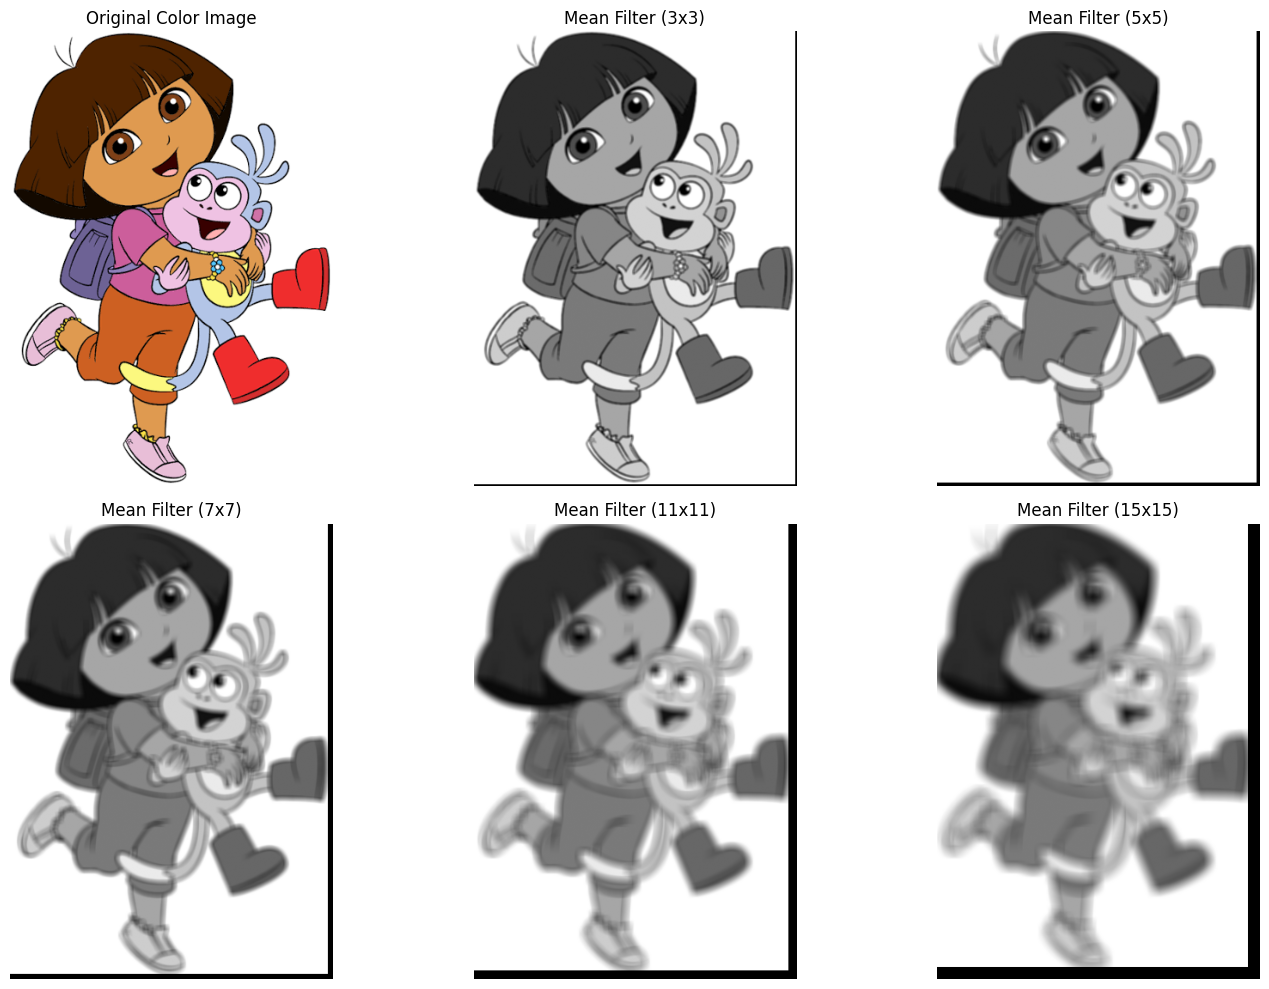

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define kernel sizes
kernel_sizes = [3, 5, 7, 11, 15]

# Load original image
img_color = cv2.imread("/content/dorabujji.png")

# Check whether image is loaded
if img_color is None:
    print("Error: Could not load image from '/content/dorabujji.png'.")
else:
    # Convert BGR to RGB for displaying with matplotlib
    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

    # Convert image to grayscale
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Get image dimensions
    m, n = img_gray.shape

    # Store filtered images
    filtered_images = {}

    # Apply mean filtering manually
    for k in kernel_sizes:

        # Create output image
        filtered_img = np.zeros((m, n), dtype=np.float32)

        # Mean filter formula:
        # g(i,j) = (1 / k^2) * sum of all pixels in k x k window

        for i in range(m - k + 1):
            for j in range(n - k + 1):

                # Extract k x k neighborhood
                window = img_gray[i:i+k, j:j+k]

                # Apply formula
                filtered_img[i, j] = np.sum(window) / (k * k)

        # Store result
        filtered_images[k] = filtered_img

    # Display original and filtered images
    plt.figure(figsize=(15, 10))

    # Original image
    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Color Image")
    plt.axis("off")

    # Display filtered images
    plot_idx = 2

    for k, f_img in filtered_images.items():
        plt.subplot(2, 3, plot_idx)
        plt.imshow(f_img.astype(np.uint8), cmap="gray")
        plt.title(f"Mean Filter ({k}x{k})")
        plt.axis("off")
        plot_idx += 1

    plt.tight_layout()
    plt.show()

Kernel size: 3x3
Output size: 529 x 374
Kernel size: 5x5
Output size: 527 x 372
Kernel size: 7x7
Output size: 525 x 370
Kernel size: 11x11
Output size: 521 x 366
Kernel size: 15x15
Output size: 517 x 362


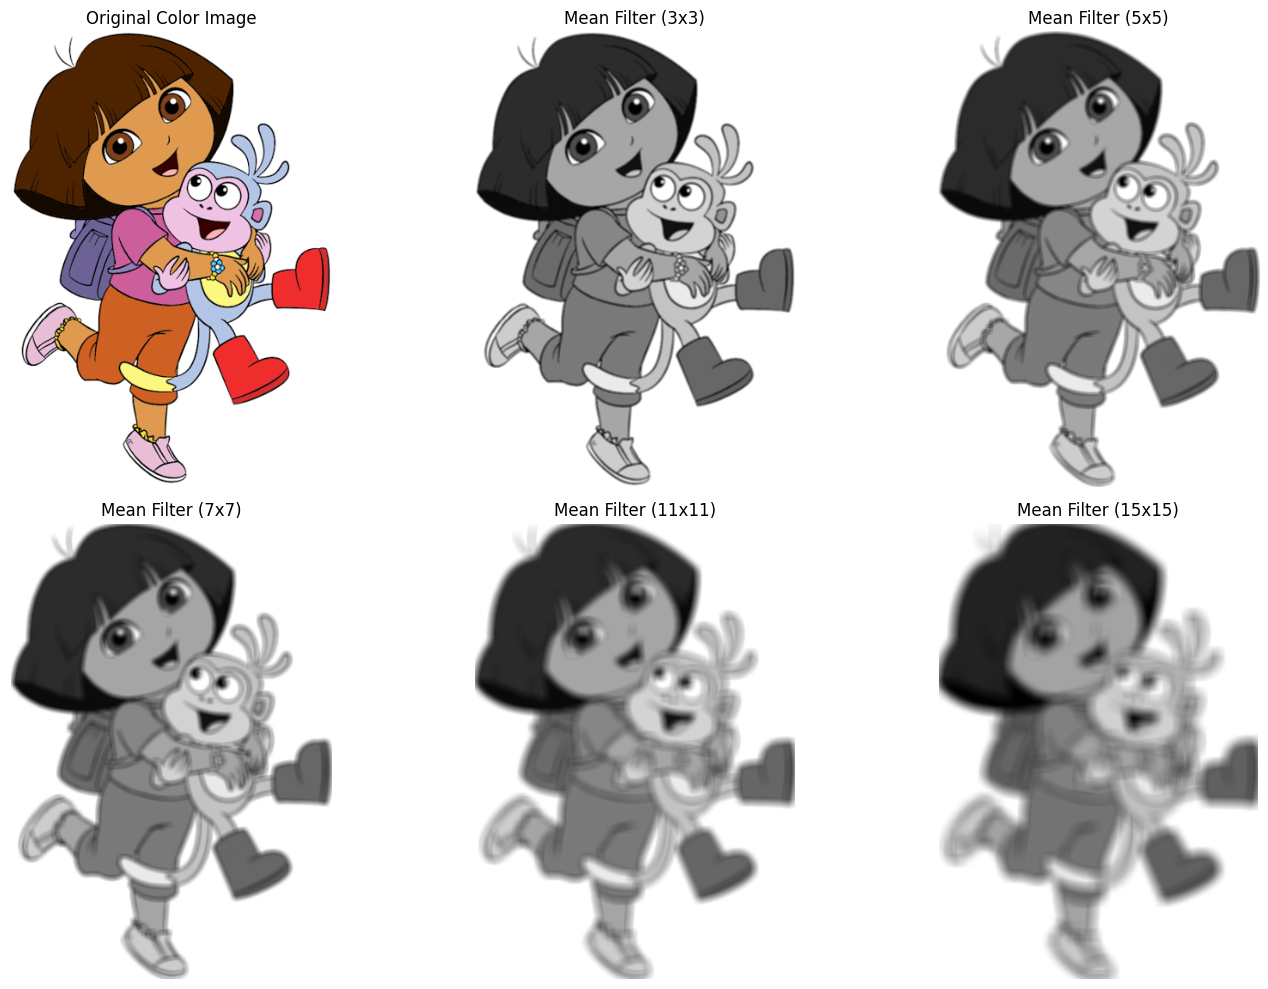

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define kernel sizes
kernel_sizes = [3, 5, 7, 11, 15]

# Padding and stride
p = 0
s = 1

# Load image
img_color = cv2.imread("/content/dorabujji.png")

# Check image
if img_color is None:
    print("Error: Could not load image.")
else:

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

    # Convert to grayscale
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Get input image dimensions
    m, n = img_gray.shape

    # Store filtered images
    filtered_images = {}

    # Apply mean filter
    for k in kernel_sizes:

        # Mean filter kernel
        kernel = np.ones((k, k), dtype=np.float32) / (k * k)

        # ------------------------------------------------
        # Output size formula:
        #
        # O = (I - K + 2P) / S + 1
        # ------------------------------------------------

        output_m = (m - k + 2 * p) // s + 1
        output_n = (n - k + 2 * p) // s + 1

        print(f"Kernel size: {k}x{k}")
        print(f"Output size: {output_m} x {output_n}")

        # Add padding if required
        if p > 0:
            padded_img = np.pad(
                img_gray,
                ((p, p), (p, p)),
                mode='constant',
                constant_values=0
            )
        else:
            padded_img = img_gray

        # Create output image using calculated size
        filtered_img = np.zeros(
            (output_m, output_n),
            dtype=np.float32
        )

        # ------------------------------------------------
        # Manual convolution
        # ------------------------------------------------

        for i in range(output_m):
            for j in range(output_n):

                # Extract k x k window
                window = padded_img[
                    i * s:i * s + k,
                    j * s:j * s + k
                ]

                # Mean filter formula
                filtered_img[i, j] = np.sum(window * kernel)

        # Store filtered image
        filtered_images[k] = filtered_img

    # ------------------------------------------------
    # Display images
    # ------------------------------------------------

    plt.figure(figsize=(15, 10))

    # Original image
    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Color Image")
    plt.axis("off")

    # Filtered images
    plot_idx = 2

    for k, f_img in filtered_images.items():

        plt.subplot(2, 3, plot_idx)

        plt.imshow(
            f_img.astype(np.uint8),
            cmap="gray"
        )

        plt.title(f"Mean Filter ({k}x{k})")
        plt.axis("off")

        plot_idx += 1

    plt.tight_layout()
    plt.show()